# 00 · Quick example: CoolCairo in one minute, offline

Runs CoolCairo's analysis on the example input in `data/sample_input/`: no downloads, no account, about 10 seconds. It uses the same functions as the full pipeline (notebooks 01–06), starting from the per-block table instead of the satellite rasters, so the numbers match the report and the app.

1. **Heat model:** what makes a 90 m block hot (east Cairo, honest spatial test)
2. **Cooling measures:** what each measure does per block
3. **Heat risk in Nasr City:** today, per measure, and for a targeted plan
4. **Urban growth 2016–2023:** are new neighbourhoods hotter?
5. **Results and maps,** written to `results/`

All temperatures are land **surface** temperature from Landsat, not air temperature. Nothing here is random (the spatial test splits by location, the models have a single exact solution), so every run gives the same numbers.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, str(Path.cwd().parent))  # analysis/, for run_example.py (relative to this notebook)

from coolcairo import growth
from coolcairo.config import REPO_ROOT, load_config
from coolcairo.interventions import (
    exposure_reduction_summary, full_adoption_deltas, heat_reference_c, targeted_plan)
from coolcairo.model import fit, training_rows

cfg = load_config()
sample = REPO_ROOT / "data" / "sample_input" / "blocks_east_cairo.csv"
blocks = pd.read_csv(sample)
print(f"{len(blocks):,} blocks of 90 m in east Cairo; {blocks.in_display.sum()} in the Nasr City district shown in the app")
blocks.head(3)

23,103 blocks of 90 m in east Cairo; 576 in the Nasr City district shown in the app


,row,col,x,y,in_display,veg_frac,dark_frac,bright_frac,roof_frac,dark_roof_frac,pale_roof_frac,dark_ground_frac,soil_frac,mean_height_m,ndvi_mean,lst_c,population,built_2016,built_2023,growth_class
0,0,0,332145.0,3333375.0,0,0.00000,0.27160,0.19753,0.0,0.0,0.0,0.27160,0.53086,0.0,0.09565,46.92494,544.12469,0.62667,0.61333,1
1,0,1,332235.0,3333375.0,0,0.00000,0.12346,0.35802,0.0,0.0,0.0,0.12346,0.51852,0.0,0.07667,46.27857,234.64902,0.47556,0.42222,1
2,0,2,332325.0,3333375.0,0,0.02469,0.02469,0.43210,0.0,0.0,0.0,0.02469,0.51852,0.0,0.10632,46.07615,189.52676,0.15556,0.12667,1


## 1 · Heat model

A linear regression explains each urban block's summer surface temperature from what it is made of (vegetation, dark roofs, dark ground, sand, building cover) and its building height. **Honest test:** whole 1 km tiles are hidden while the model learns, then predicted; neighbouring blocks share heat, so hiding single blocks would overstate the accuracy.

In [2]:
train = training_rows(blocks, cfg["min_building_coverage"])
result = fit(train, cfg["cv_tile_size"], cfg["cv_folds"])
print(f"Urban blocks (≥10% building cover): {result.n_blocks:,}")
print(f"Spatial cross-validated R² {result.r2_spatial_cv:.2f}, mean error ±{result.mae_spatial_cv:.1f} °C")
pd.Series(result.coefficients, name="°C if the whole block were this surface (vs pale ground)").round(2).to_frame()

Urban blocks (≥10% building cover): 2,538
Spatial cross-validated R² 0.25, mean error ±1.2 °C


,°C if the whole block were this surface (vs pale ground)
veg_frac,-3.15
dark_roof_frac,-11.28
dark_ground_frac,0.12
soil_frac,3.36
roof_frac,2.29
mean_height_m,-0.06


Vegetation cools and sand heats, as expected. The dark-roof number is **implausible** (dark roofs absorb more sun): building shadow is read as dark roof. That is why the cool-roof tool uses published physics (−4.64 °C per unit of dark roof coated) instead of this coefficient.

## 2 · Cooling measures

Each measure at full adoption within its limit (trees on up to 25% of dark ground, parks on up to 50% of sand), as °C change per block.

In [3]:
effects = full_adoption_deltas(cfg, result, train)
effects.describe().T[["mean", "min", "max"]].round(2)

,mean,min,max
cool_roofs,-1.01,-3.66,-0.06
street_trees,-0.09,-0.64,-0.00
cool_pavements,-0.25,-1.74,-0.00
pocket_parks,-0.74,-2.90,-0.00


## 3 · Heat risk in Nasr City

**Heat exposure** = residents × degrees above a typical east-Cairo block (person·°C). A hot empty lot matters less than a hot block where many people live.

In [4]:
reference = heat_reference_c(cfg, train)
display_blocks = blocks[blocks.in_display == 1]
measured = display_blocks.dropna(subset=["lst_c"])
risk = exposure_reduction_summary(cfg, result, measured, reference)
print(f"Typical block {reference:.1f} °C · {risk.residents:,.0f} residents · "
      f"heat exposure {risk.exposure_person_degC:,.0f} person·°C today")
risk.filter(like="_pct").round(0).rename("% change, one measure in every block").to_frame()

Typical block 45.7 °C · 95,141 residents · heat exposure 6,460 person·°C today


,"% change, one measure in every block"
cool_roofs_pct,-41.0
street_trees_pct,-24.0
cool_pavements_pct,-52.0
pocket_parks_pct,-60.0


In [5]:
plan = targeted_plan(cfg, result, display_blocks, reference)
print(f"Cool roofs + pocket parks on only the riskiest third ({plan['blocks']} of {len(measured)} blocks):")
print(f"  heat exposure {plan['exposure_before']:,.0f} -> {plan['exposure_after']:,.0f} person·°C "
      f"({plan['exposure_change_pct']:+.0f}%), {plan['residents_cooled']:,.0f} residents in cooled blocks")

Cool roofs + pocket parks on only the riskiest third (192 of 576 blocks):
  heat exposure 6,460 -> 1,686 person·°C (-74%), 22,588 residents in cooled blocks


**Targeting beats spreading:** cooling a third of the blocks, chosen by risk, removes more exposure than any single measure applied everywhere. This is the plan shown in the app screenshots and the report.

## 4 · Urban growth 2016–2023

Building cover per block from Google Open Buildings Temporal, classed with the model's 10% urban cut-off.

In [6]:
g = cfg["growth"]
blocks["transition"] = growth.transitions(blocks, g["first_year"], g["last_year"], g["built_block_min"])
area = growth.built_area_km2(blocks, cfg.block_size)
first, last = g["first_year"], g["last_year"]
print(f"Building footprint {area[first]:.1f} -> {area[last]:.1f} km² ({100 * (area[last] / area[first] - 1):+.1f}%)")
growth.heat_by_transition(blocks).round(2)

Building footprint 37.1 -> 39.2 km² (+5.7%)


,blocks,mean_lst_c,median_lst_c
transition,,,
Built before 2016,13323,45.95,45.72
Built 2016-2023,988,46.91,46.75
Still open,8792,48.57,48.95


New neighbourhoods are about 1 °C hotter than established ones, though cooler than the open desert they replace: the time to design cooling in is while an area is being built.

## 5 · Results and maps

Writes every result to `results/` (JSON, CSV, maps, `summary.md`) with the same steps (`analysis/run_example.py`).

Written: cooling_effects_per_block_degC.csv, heat_risk_nasr_city.json, model_fit.json, nasr_city_after_targeted_plan.png, nasr_city_heat_exposure.png, nasr_city_surface_temperature.png, summary.md, urban_growth_heat_by_class.csv


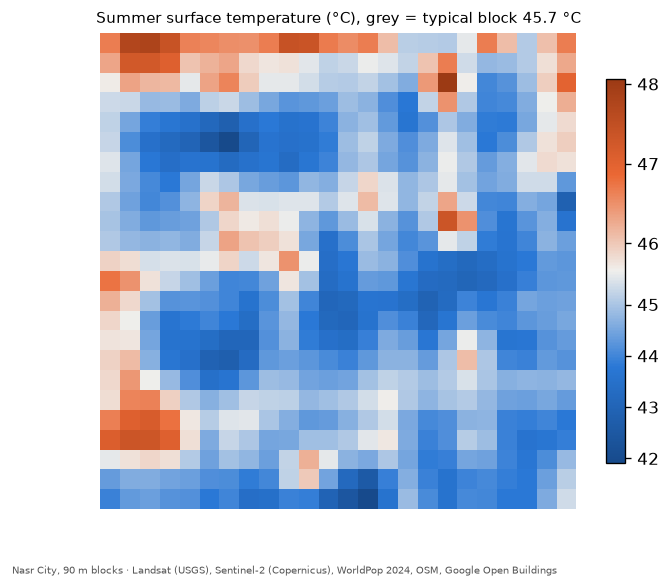

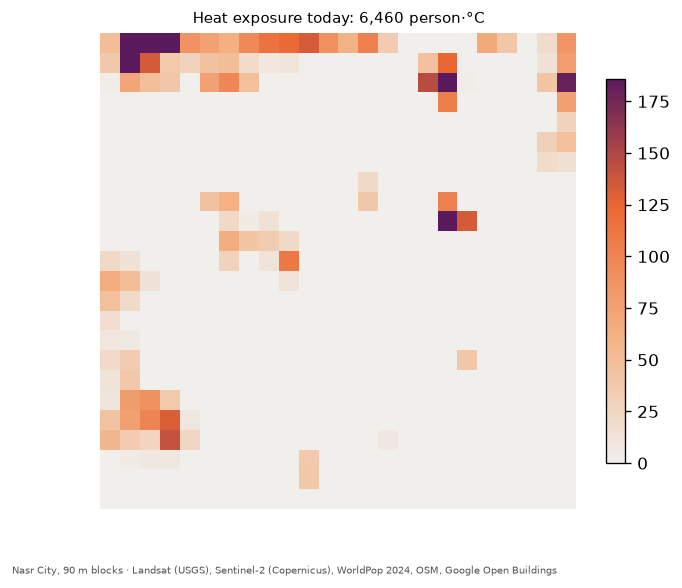

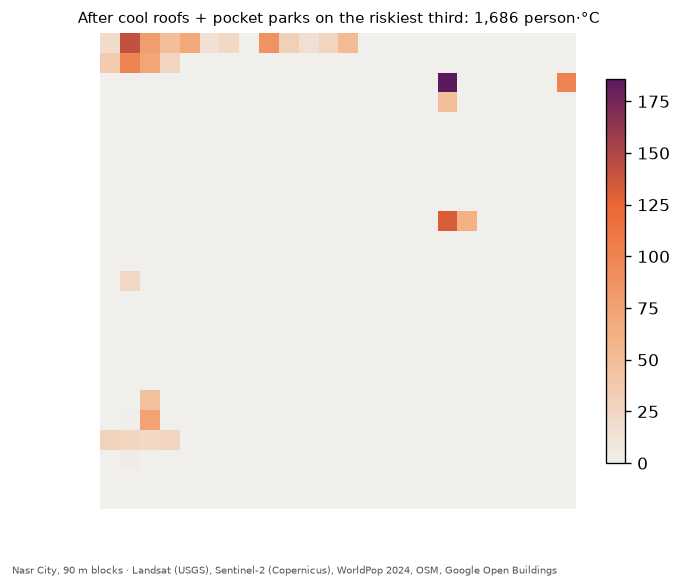

In [7]:
import run_example

out = run_example.run()
print("Written:", ", ".join(sorted(p.name for p in run_example.RESULTS.iterdir())))
for name in ("nasr_city_surface_temperature.png", "nasr_city_heat_exposure.png",
             "nasr_city_after_targeted_plan.png"):
    display(Image(filename=str(run_example.RESULTS / name), width=520))

**Same numbers as the report and the app:** R² 0.25 · 6,460 person·°C today · −41 / −24 / −52 / −60% for one measure everywhere · −74% for the targeted plan (22,588 residents cooled) · +5.7% building footprint, new blocks 46.9 °C vs 46.0 °C established. `uv run pytest` checks these automatically (`tests/test_example.py`).

Data: Landsat (USGS) · Contains modified Copernicus Sentinel data [2023–2025] · WorldPop 2024 (CC BY 4.0) · © OpenStreetMap contributors · Google Open Buildings 2.5D Temporal (CC BY 4.0).